# XLand-MiniGrid Data Analysis


In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
from nicewebrl import data_analysis
from flax import serialization
import jax

In [106]:
from nicewebrl.utils import read_all_records

file_path = "/Users/vikramgoddla/nicewebrl_LLM_EnvStage/nicewebrl/examples/xland-LLM-assistant/data/user_data_3210147396.msgpack"
data_dicts = await read_all_records(file_path)

In [107]:
len(data_dicts)

154

In [108]:
from collections import Counter

# Count field frequencies inside "data"
field_counts = Counter(k for d in data_dicts for k in d.get('data', {}).keys())
print(field_counts.most_common(20))

# Peek at the last few records to see why [-1] didn't have action_taken_time
for d in data_dicts[-5:]:
    print(d.get('type'), list(d.get('data', {}).keys()))

[('image_seen_time', 153), ('action_taken_time', 153), ('computer_interaction', 153), ('action_name', 153), ('action_idx', 153), ('timelimit', 153), ('timestep', 153), ('event', 153), ('How helpful was the AI?', 1), ('How human-like was the AI?', 1)]
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'event']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'event']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'event']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'event']
None ['How helpful was the AI?', 'How human-like was the AI?']


In [109]:
def has_keys(d, *ks):
    return all(k in d.get('data', {}) for k in ks)

action_recs = [d for d in data_dicts
               if has_keys(d, 'image_seen_time', 'action_taken_time')]
print(len(action_recs), "action timesteps")

153 action timesteps


In [110]:
from nicewebrl import time_diff

def has_str(d, key):
    v = d.get('data', {}).get(key)
    return isinstance(v, str) and len(v) > 0

# keep only *valid* action records with both times present as strings
action_recs = [
    d for d in data_dicts
    if has_str(d, 'image_seen_time') and has_str(d, 'action_taken_time')
]

# FIRST valid image_seen_time anywhere in the stream
first_image_ts = next(
    d['data']['image_seen_time'] for d in data_dicts if has_str(d, 'image_seen_time')
)

# LAST valid action_taken_time among action records
last_action_ts = next(
    d['data']['action_taken_time'] for d in reversed(action_recs)
)

start_end_sec = time_diff(first_image_ts, last_action_ts) / 1000
print(f"Total seconds from first timestep to last action: {start_end_sec:.2f}")

pair_ms = [
    time_diff(d['data']['image_seen_time'], d['data']['action_taken_time'])
    for d in action_recs
]
total_timestep_sec = sum(pair_ms) / 1000
print(f"Total seconds across image–action pairs: {total_timestep_sec:.2f}")

Total seconds from first timestep to last action: 54.98
Total seconds across image–action pairs: 65.48


In [111]:
from pprint import pprint

datum = data_dicts[0]
print("-----")
pprint(list(datum.keys()))
print("--- data ---")
pprint(list(datum["data"].keys()))

-----
['stage_idx', 'session_id', 'data', 'user_data', 'metadata', 'name', 'body']
--- data ---
['image_seen_time',
 'action_taken_time',
 'computer_interaction',
 'action_name',
 'action_idx',
 'timelimit',
 'timestep',
 'event']


In [112]:
print("------")

for key in [
  # "id",  # time-step idx. global
  "session_id",  # browser session id
  "stage_idx",
]:
  print(key, ":", datum[key])

print("--- data ---")
for key in [
  "image_seen_time",
  "action_taken_time",
  "computer_interaction",
  "action_name",
  "action_idx",
]:
  print(key, ":", datum["data"][key])

------
session_id : 605c6f63-189f-4894-94d3-18e1d1e948ec
stage_idx : 1
--- data ---
image_seen_time : 2025-09-23T20:05:41.551Z
action_taken_time : 2025-09-23T20:05:54.714Z
computer_interaction : ArrowRight
action_name : Right
action_idx : 1


In [113]:
type(datum['data'].keys())
datum['data'].keys()

dict_keys(['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'event'])

In [114]:
datum["metadata"]  # remember, this is for the VERY FIRST timestep of this episode

{'stage_number': 1,
 'type': 'EnvStage',
 'unique_id': 'stage_a797ed13ff234174805b50315b4f9ea0',
 'nsteps': 2,
 'nepisodes': 1,
 'nsuccesses': 0}

In [115]:
datum["user_data"]

{'user_id': 3210147396, 'age': 19, 'sex': 'Male'}

In [116]:
def is_str(v): return isinstance(v, str) and len(v) > 0

img_idxs, img_ts = [], []
act_idxs, act_ts = [], []
for i, d in enumerate(data_dicts):
    dd = d.get('data', {})
    if is_str(dd.get('image_seen_time')):
        img_idxs.append(i); img_ts.append(dd['image_seen_time'])
    if is_str(dd.get('action_taken_time')):
        act_idxs.append(i); act_ts.append(dd['action_taken_time'])

print(f"records={len(data_dicts)}  images={len(img_idxs)}  actions={len(act_idxs)}")
print("first image idx:", img_idxs[0] if img_idxs else None, "| ts:", img_ts[0] if img_ts else None)
print("first action idx:", act_idxs[0] if act_idxs else None, "| ts:", act_ts[0] if act_ts else None)
print("image idxs (first 10):", img_idxs[:10])
print("action idxs (first 10):", act_idxs[:10])


records=154  images=153  actions=153
first image idx: 0 | ts: 2025-09-23T20:05:41.551Z
first action idx: 0 | ts: 2025-09-23T20:05:54.714Z
image idxs (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
action idxs (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [117]:
datum = data_dicts[0]["data"]
action_taken: int = datum["action_idx"]
image_seen_time: str = datum["image_seen_time"]
action_taken_time: str = datum["action_taken_time"]
reaction_time: float = data_analysis.compute_reaction_time(datum)

print(f"Reaction time: {reaction_time:.2f} milliseconds")

Reaction time: 13163.00 milliseconds


In [118]:
import jax
from experiment_structure import jax_env, env_params, render_fn

example_timestep = jax_env.reset(key=jax.random.PRNGKey(0), params=env_params)

=== Example timestep ===
idx: 0
stage: Environment 1
action/key: Right
image_seen_time: 2025-09-23T20:05:41.551Z
action_taken_time: 2025-09-23T20:05:54.714Z
llm_chat_history (latest turn):
  prompt  : 'what is the goal here?'
  response: 'The goal is to get the agent near the blue square.'
  ts      : 2025-09-23T20:05:51.631557+00:00


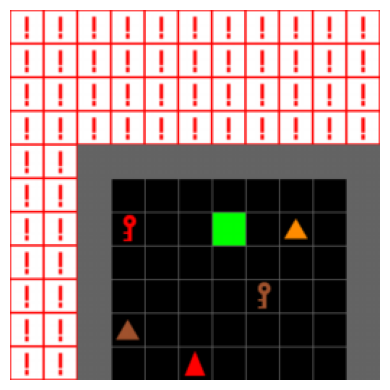

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from flax import serialization

# --- pick a renderer from your codebase ---
try:
    from experiment_structure import render_fn as RENDER
except Exception:
    RENDER = None

def show_one_timestep(data_dicts, example_timestep, idx=0):
    assert RENDER is not None, (
        "Couldn't import a renderer. Ensure experiment_structure.py exports `render_fn`, "
        "or set RENDER to your renderer function."
    )
    assert 0 <= idx < len(data_dicts), f"idx {idx} out of range (len={len(data_dicts)})"

    rec = data_dicts[idx]
    meta = rec.get("metadata", {})
    dd   = rec.get("data", {})

    # reconstruct the timestep
    ts_bytes = dd["timestep"]
    timestep = serialization.from_bytes(example_timestep, ts_bytes)

    # render image
    img = RENDER(timestep).astype(np.uint8)

    # pull a few fields for a readable printout
    stage    = rec.get("name")
    key_name = dd.get("action_name") or dd.get("computer_interaction")
    img_t    = dd.get("image_seen_time")
    act_t    = dd.get("action_taken_time")

    # llm history (if present)
    llm_hist = None
    # new location (under event.args, if you saved it there)
    if "event" in dd and "args" in dd["event"]:
        llm_hist = dd["event"]["args"].get("llm_chat_history")
    # common legacy location
    if llm_hist is None:
        llm_hist = dd.get("llm_chat_history")

    print("=== Example timestep ===")
    print(f"idx: {idx}")
    print(f"stage: {stage}")
    print(f"action/key: {key_name}")
    print(f"image_seen_time: {img_t}")
    print(f"action_taken_time: {act_t}")
    if llm_hist:
        # show brief view of latest turn
        latest = llm_hist[-1] if isinstance(llm_hist, list) else llm_hist
        print("llm_chat_history (latest turn):")
        print(f"  prompt  : {latest.get('prompt')!r}")
        print(f"  response: {latest.get('response')!r}")
        print(f"  ts      : {latest.get('timestamp')}")
    else:
        print("llm_chat_history: <none>")

    # display the image
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# --- example usage ---
show_one_timestep(data_dicts, example_timestep, idx=0)  # change idx to inspect a different record

In [120]:
rec0_keys = sorted((data_dicts[0].get("data") or {}).keys())
print(rec0_keys)

['action_idx', 'action_name', 'action_taken_time', 'computer_interaction', 'event', 'image_seen_time', 'timelimit', 'timestep']


In [ ]:
## show the path to the llm_chat_history
display(data_dicts[0].get("data")['event']['args']['llm_chat_history'])

[{'prompt': 'what is the goal here?',
  'response': 'The goal is to get the agent near the blue square.',
  'timestamp': '2025-09-23T20:05:51.631557+00:00'}]

In [124]:
# print(data_dicts[0].keys())
# print(data_dicts[0]['data'].keys())
import jax
from pprint import pprint

pprint(jax.tree.map(lambda x: type(x), data_dicts[19]))


{'body': <class 'str'>,
 'data': {'action_idx': <class 'int'>,
          'action_name': <class 'str'>,
          'action_taken_time': <class 'str'>,
          'computer_interaction': <class 'str'>,
          'event': {'args': {'AT_TARGET': <class 'int'>,
                             'BUBBLING_PHASE': <class 'int'>,
                             'CAPTURING_PHASE': <class 'int'>,
                             'DOM_KEY_LOCATION_LEFT': <class 'int'>,
                             'DOM_KEY_LOCATION_NUMPAD': <class 'int'>,
                             'DOM_KEY_LOCATION_RIGHT': <class 'int'>,
                             'DOM_KEY_LOCATION_STANDARD': <class 'int'>,
                             'NONE': <class 'int'>,
                             '_vts': <class 'int'>,
                             'altKey': <class 'bool'>,
                             'bubbles': <class 'bool'>,
                             'cancelBubble': <class 'bool'>,
                             'cancelable': <class 'bool'>,
  